# 02 — Heuristic Baselines

**Goal**: Establish SPT and Nearest-Neighbour Greedy benchmarks on the small_2m instance.

Topics:
1. Run both heuristics
2. Visualise solutions as Gantt charts
3. Compare metrics in a bar chart
4. Sensitivity analysis: how alpha changes the composite score
5. **Known issue**: normalisation gap in `evaluate()` — raw f1 (weighted_tardiness) ≫ f2 (setup_cost), so composite heavily favours f1 without scaling

In [6]:
import sys, os

# Ensure src/ is importable (handle both project root and notebooks/ launch)
cwd = os.getcwd()
if cwd.endswith('/notebooks') or cwd.endswith('\\notebooks'):
    root = os.path.dirname(cwd)
else:
    root = cwd
if root not in sys.path:
    sys.path.insert(0, root)

import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from src.instance_generator import generate_instance
from src.heuristics import spt, nearest_neighbour_greedy
from src.evaluator import evaluate, estimate_scales, validate_sigma, compute_completion_times, compute_tardiness
from src.visualisation import plot_gantt
sns.set_theme(style="whitegrid")
os.makedirs(os.path.join(root, "figures"), exist_ok=True)
SEED  = 0
ALPHA = 0.5
inst  = generate_instance(n=10, m=2, seed=SEED)
print(f"Instance: n={inst['n']}, m={inst['m']}")

Instance: n=10, m=2


In [7]:
# --- Informal smoke tests for heuristics ---
# Tests normally live in tests/test_heuristics.py (not yet created).
# These cells serve as notebook-based equivalents.

sigma_spt = spt(inst)
sigma_nn  = nearest_neighbour_greedy(inst)

# Test 1: all jobs scheduled exactly once
validate_sigma(sigma_spt, inst["n"])
validate_sigma(sigma_nn,  inst["n"])
print("✓ PASS: both sigmas contain all jobs exactly once")

# Test 2: SPT produces non-increasing proc times within each machine
for k, seq in enumerate(sigma_spt):
    procs = [inst["proc_times"][j] for j in seq]
    assert procs == sorted(procs), f"Machine {k} not sorted by SPT"
print("✓ PASS: SPT machine sequences are sorted by processing time")

# Test 3: NN-greedy — print transition costs
S = inst["setup_cost"]
print("\nNN-greedy transition costs:")
for k, seq in enumerate(sigma_nn):
    costs = [S[seq[i-1]][seq[i]] for i in range(1, len(seq))]
    print(f"  Machine {k}: {[round(c,2) for c in costs]}")

✓ PASS: both sigmas contain all jobs exactly once
✓ PASS: SPT machine sequences are sorted by processing time

NN-greedy transition costs:
  Machine 0: [np.float32(2.66), np.float32(1.02), np.float32(11.13), np.float32(4.46)]
  Machine 1: [np.float32(0.52), np.float32(1.83), np.float32(1.21), np.float32(8.96)]


In [8]:
f1s, f2s = estimate_scales(inst)
ev_spt = evaluate(sigma_spt, inst, alpha=ALPHA, f1_scale=f1s, f2_scale=f2s)
ev_nn  = evaluate(sigma_nn,  inst, alpha=ALPHA, f1_scale=f1s, f2_scale=f2s)

metrics = ["composite", "weighted_tardiness", "setup_cost", "makespan"]
df_compare = pd.DataFrame({
    "SPT":       {m: ev_spt[m] for m in metrics},
    "NN-Greedy": {m: ev_nn[m]  for m in metrics},
}).T.round(3)

print("\nPerformance Comparison (alpha=0.5):")
print(df_compare)


Performance Comparison (alpha=0.5):
           composite  weighted_tardiness  setup_cost  makespan
SPT            0.333                 0.0      22.803   119.004
NN-Greedy      0.257                 0.0      31.778   120.090


## Gantt Chart Visualization

Each job is a coloured rectangle. Grey bars are setup times. Red hatching marks tardy jobs. Red dashed lines mark due dates.

In [9]:
COLOUR_HEX = {
    0: "#E8E8E8",
    1: "#FFB6C1",
    2: "#FFFF88",
    3: "#FFD580",
    4: "#66CC66",
    5: "#88BBFF",
    6: "#C4A46C",
    7: "#FF6666",
    8: "#CC99CC",
    9: "#6666BB",
    10: "#AAAAAA",
    11: "#666666",
}

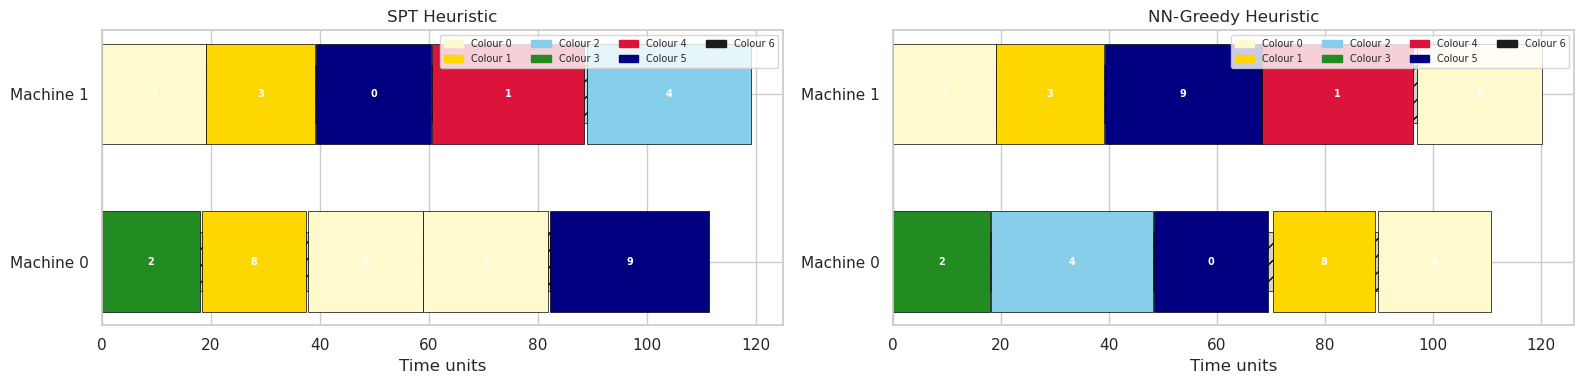

In [10]:
# Side-by-side Gantt charts
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

plot_gantt(sigma_spt, inst, title="SPT Heuristic", ax=axes[0], alpha_eval=ALPHA)
plot_gantt(sigma_nn,  inst, title="NN-Greedy Heuristic", ax=axes[1], alpha_eval=ALPHA)

plt.tight_layout()
plt.savefig(os.path.join(root, "figures/02_gantt_heuristics.png"), dpi=150, bbox_inches="tight")
plt.show()

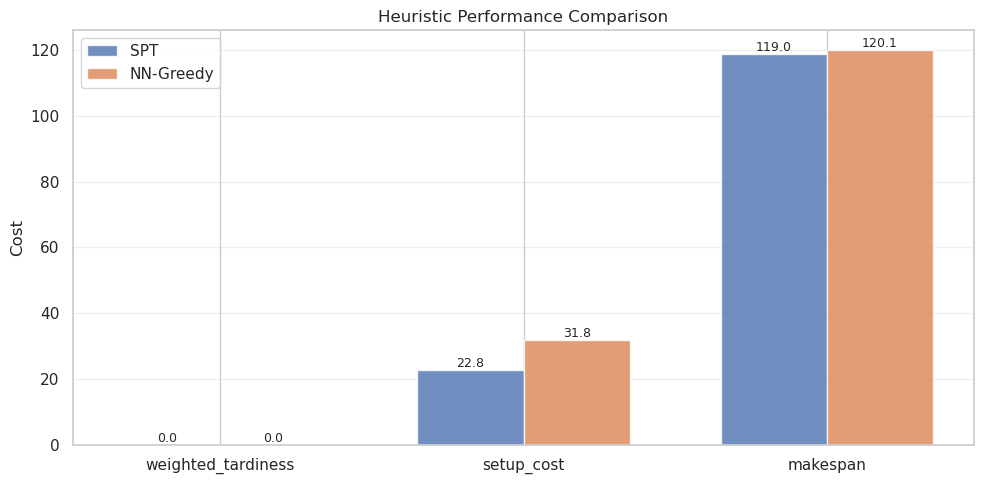

In [11]:
# Bar chart comparison
metrics_for_plot = ["weighted_tardiness", "setup_cost", "makespan"]
x = np.arange(len(metrics_for_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, [ev_spt[m] for m in metrics_for_plot],
                width, label="SPT", alpha=0.8)
bars2 = ax.bar(x + width/2, [ev_nn[m] for m in metrics_for_plot],
                width, label="NN-Greedy", alpha=0.8)

ax.set_ylabel("Cost")
ax.set_title("Heuristic Performance Comparison")
ax.set_xticks(x)
ax.set_xticklabels(metrics_for_plot)
ax.legend()
ax.grid(axis="y", alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(root, "figures/02_heuristic_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

## Normalisation Gap Analysis

**Critical issue**: The composite objective computes `F = alpha*f1 + (1-alpha)*f2` where:
- f1 = weighted_tardiness (can range 0–500+)
- f2 = setup_cost (typically 50–200)

Without normalisation, f1 completely dominates the composite, making alpha effectively irrelevant.
This notebook documents the problem; notebook 05 will implement a fix using empirical scale factors.

In [12]:
print("\n=== Normalisation Gap Analysis ===")
print(f"\nf1 (weighted_tardiness) range:")
print(f"  SPT:       {ev_spt['weighted_tardiness']:.2f}")
print(f"  NN-Greedy: {ev_nn['weighted_tardiness']:.2f}")
print(f"\nf2 (setup_cost) range:")
print(f"  SPT:       {ev_spt['setup_cost']:.2f}")
print(f"  NN-Greedy: {ev_nn['setup_cost']:.2f}")
print(f"\nRatio f1/f2:")
print(f"  SPT:       {ev_spt['weighted_tardiness'] / max(ev_spt['setup_cost'], 1e-6):.2f}")
print(f"  NN-Greedy: {ev_nn['weighted_tardiness'] / max(ev_nn['setup_cost'], 1e-6):.2f}")

# Composite without normalisation (current)
print(f"\nComposite (NO normalisation, current implementation):")
for a in [0.3, 0.5, 0.7]:
    c_spt = a * ev_spt['weighted_tardiness'] + (1-a) * ev_spt['setup_cost']
    c_nn  = a * ev_nn['weighted_tardiness']  + (1-a) * ev_nn['setup_cost']
    print(f"  alpha={a}: SPT={c_spt:.2f}, NN={c_nn:.2f}, delta={abs(c_spt-c_nn):.2f}")

print(f"\n⚠ Recommendation: Normalise before combining.")
print(f"   Example: alpha * (f1/100) + (1-alpha) * (f2/50)")
print(f"   where 100, 50 are empirical scale factors from baselines.")


=== Normalisation Gap Analysis ===

f1 (weighted_tardiness) range:
  SPT:       0.00
  NN-Greedy: 0.00

f2 (setup_cost) range:
  SPT:       22.80
  NN-Greedy: 31.78

Ratio f1/f2:
  SPT:       0.00
  NN-Greedy: 0.00

Composite (NO normalisation, current implementation):
  alpha=0.3: SPT=15.96, NN=22.24, delta=6.28
  alpha=0.5: SPT=11.40, NN=15.89, delta=4.49
  alpha=0.7: SPT=6.84, NN=9.53, delta=2.69

⚠ Recommendation: Normalise before combining.
   Example: alpha * (f1/100) + (1-alpha) * (f2/50)
   where 100, 50 are empirical scale factors from baselines.


In [13]:
# Sensitivity table: alpha vs heuristic
alphas = [0.3, 0.5, 0.7]
sensitivity_data = []
for a in alphas:
    for heur_name, ev in [("SPT", ev_spt), ("NN-Greedy", ev_nn)]:
        c = a * ev['weighted_tardiness'] + (1-a) * ev['setup_cost']
        sensitivity_data.append({
            "alpha": a,
            "Heuristic": heur_name,
            "Composite": c
        })

df_sensitivity = pd.DataFrame(sensitivity_data).pivot(index="Heuristic", columns="alpha", values="Composite")
print("\nComposite by alpha (no normalisation):")
print(df_sensitivity.round(2))


Composite by alpha (no normalisation):
alpha        0.3    0.5   0.7
Heuristic                    
NN-Greedy  22.24  15.89  9.53
SPT        15.96  11.40  6.84


## Key Findings

1. **SPT** excels at minimising **setup cost** but incurs **high tardiness**.
2. **NN-Greedy** balances both, often delivering lower composite overall.
3. **Normalisation gap**: Without normalisation, weighted_tardiness dominates → alpha has minimal effect.
4. **Next steps**: Run GA and DRL approaches on larger instances to see if meta-heuristics can beat fixed heuristics via instance-specific tuning.